In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Signal tree memory consumption

A signal tree is a perfect binary tree, i.e. it has a power of two number of signals.
 - Total number of signals: N
 - Number of leaf nodes: N
 - Number of levels: log_2(N)
 - 

In [3]:
def bits_per_counter(reversed_level):
    return reversed_level + 1
def nodes_for_level(level):
    return 1 << level

def bytes_per_inner_level(level: int, max_levels = 0):
    nodes = nodes_for_level(level)
    if max_levels > 0:
        # optimal: counter uses exactly as many bits as required for this level
        # counters near the leaf level need much less bits because the maximum number
        # doubles for each level "above" the leaf nodes, starting at 1 bit (for the leaf nodes themselves)
        bpc = bits_per_counter(max_levels - level)
        counters_per_atomic = int(np.floor(64 / bpc))
        needed_atomics = int(np.ceil(nodes / counters_per_atomic))
        return needed_atomics * 8
    else:
        # naive: counter uses 8 bytes (full 64bit counter)
        return nodes * 8

In [4]:
num_signals = 1 << 16
optimal = True
num_levels = int(np.log2(num_signals)) + 1
nodes_per_level = [1 << l for l in range(num_levels)]

print(f"total_signals: {num_signals}")
print(f"num_levels: {num_levels}")
print(f"nodes_per_level: {nodes_per_level}")
    
bytes_inner_levels = [bytes_per_inner_level(l, num_levels if optimal else 0) for l in range(num_levels-1)]
print(f"bytes per inner level: {bytes_inner_levels}")

# one bit per node for leaf nodes - stored in 64bit atomics, so round up
bytes_for_leaf_level = int(np.ceil(nodes_per_level[-1] / (64 * 8)) * 8)
print(f"Bytes for leaf level: {bytes_for_leaf_level}")

total_bytes = sum(bytes_inner_levels) + bytes_for_leaf_level
print(f"Total memory: {total_bytes} B = {total_bytes / 1024 :.2f} KiB")
print(f"Bytes per signal: {total_bytes / num_signals} B")

total_signals: 65536
num_levels: 17
nodes_per_level: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]
bytes per inner level: [8, 8, 8, 16, 32, 64, 104, 208, 344, 592, 1024, 1824, 3280, 5464, 8192, 12488]
Bytes for leaf level: 1024
Total memory: 34680 B = 33.87 KiB
Bytes per signal: 0.5291748046875 B


In [5]:
def tree_size(num_signals, optimal: bool = False):
    num_levels = int(np.log2(num_signals)) + 1
    inner_levels = [bytes_per_inner_level(l, num_levels if optimal else 0) for l in range(num_levels-1)]
    leaf_level = int(np.ceil(nodes_for_level(num_levels-1) / (64 * 8)) * 8)
    total_bytes = sum(inner_levels) + leaf_level

    return total_bytes

In [6]:
tree_size(1 << 16, True)

34680

In [7]:
def readable_size(bytes):
    rounded = bytes
    unit = "B"
    if rounded > 1024:
        rounded = np.round(rounded / 1024)
        unit = "KiB"
    if rounded > 1024:
        rounded = np.round(rounded / 1024)
        unit = "MiB"
    if rounded > 1024:
        rounded = np.round(rounded / 1024)
        unit = "GiB"
    return f"{rounded :.2f} {unit}"

In [12]:
# Create a DataFrame with the first column
data = {'num_signals': [1 << l for l in range(24)]}
df = pd.DataFrame(data)

def tree_size_naive(num_signals):
    return tree_size(num_signals, False)

def tree_size_optimal(num_signals):
    return tree_size(num_signals, True)

# Apply the function to the first column and create a new column with the results
df['Size (naive)'] = df['num_signals'].apply(tree_size_naive)
df['Size (naive) rd'] = df['Size (naive)'].apply(readable_size)

df['Size (optimal)'] = df['num_signals'].apply(tree_size_optimal)
df['Size (optimal) rd'] = df['Size (optimal)'].apply(readable_size)

df['Overhead (naive/optimal)'] = df['Size (naive)'] / df['Size (optimal)']
df['Bytes/signal (naive)'] = df['Size (naive)'] / df['num_signals']
df['Bytes/signal (optimal)'] = df['Size (optimal)'] / df['num_signals']


df

,num_signals,Size (naive),Size (naive) rd,Size (optimal),Size (optimal) rd,Overhead (naive/optimal),Bytes/signal (naive),Bytes/signal (optimal)
0,1,8,8.00 B,8,8.00 B,1.000000,8.000000,8.000000
1,2,16,16.00 B,16,16.00 B,1.000000,8.000000,8.000000
2,4,32,32.00 B,24,24.00 B,1.333333,8.000000,6.000000
3,8,64,64.00 B,32,32.00 B,2.000000,8.000000,4.000000
4,16,128,128.00 B,40,40.00 B,3.200000,8.000000,2.500000
5,32,256,256.00 B,48,48.00 B,5.333333,8.000000,1.500000
6,64,512,512.00 B,64,64.00 B,8.000000,8.000000,1.000000
7,128,1024,1024.00 B,104,104.00 B,9.846154,8.000000,0.812500
8,256,2048,2.00 KiB,168,168.00 B,12.190476,8.000000,0.656250
9,512,4096,4.00 KiB,304,304.00 B,13.473684,8.000000,0.593750


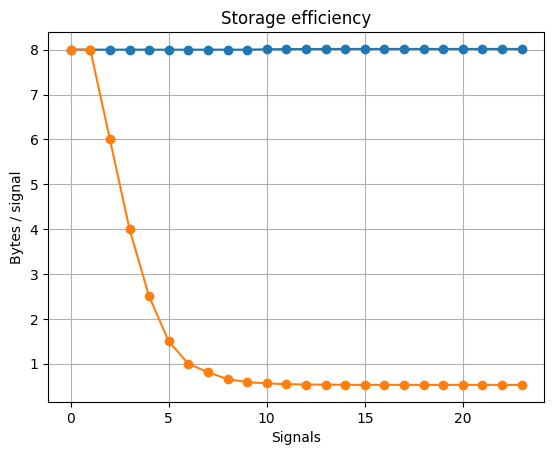

In [15]:
plt.plot(df['Bytes/signal (naive)'], marker='o')
plt.plot(df['Bytes/signal (optimal)'], marker='o')
#plt.plot(df['Overhead (naive/optimal)'], marker='o')
plt.title('Storage efficiency')
plt.xlabel('Signals')
plt.ylabel('Bytes / signal')
plt.grid(True)
plt.show()

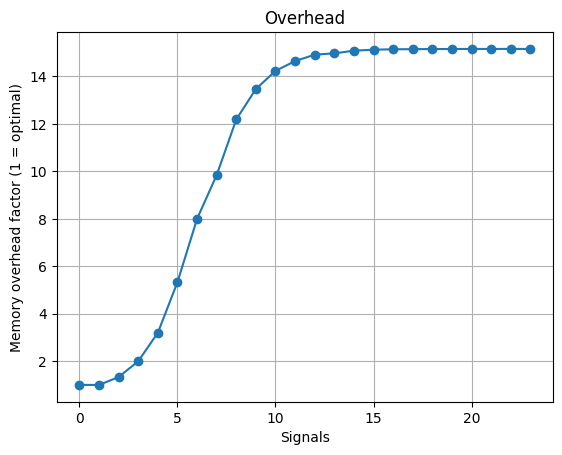

In [18]:
plt.plot(df['Overhead (naive/optimal)'], marker='o')
plt.title('Overhead')
plt.xlabel('Signals')
plt.ylabel('Memory overhead factor (1 = optimal)')
plt.grid(True)
plt.show()